In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from limvam.micado import micado

# Generate data

In this section, we generate data according to the model xi = Bi xi + Di s + ni, where:
- i represents the view index
- xi are the observations
- Bi are adjacency matrices of Directed Acyclic Graphs (DAGs) that can share different causal orderings
- Di are diagonal matrices that scale sources
- s are the shared sources following a Gaussian or a Laplacian distribution
- ni are Gaussian disturbances.

In [2]:
# parameters
m = 5
p = 4
n = 1000
nb_gaussian_disturbances = 2  # should be between 0 and p
shared_causal_ordering = True
ica_algo = "shica_ml"  # either "shica_ml" or "shica_j"
random_state = 42
rng = np.random.RandomState(random_state)

In [3]:
def generate_data(
    m,
    p,
    n,
    rng=None,
    nb_gaussian_disturbances=0,
    shared_causal_ordering=True,
):
    """
    Generate data according to the model xi = Bi xi + Di s + ni, where the Bi are DAG matrices.
        
    Parameters
    ----------
    m : Number of views (int)
    p : Number of components (int)
    n : Number of samples (int)
    rng : Random seed 
    nb_gaussian_disturbances : Number of Gaussians in s; the other sources are Laplacian (int; default 0)
    shared_causal_ordering : True if all DAG matrices share the same causal ordering; False otherwise.

    Returns
    -------
    X : Training data (ndarray of shape (m, p, n))
    S : Shared sources (ndarray of shape (p, n))
    B : DAG matrices (ndarray of shape (m, p, p))
    T : Strictly lower triangular matrices (ndarray of shape (m, p, p))
    P : Permutation matrices (ndarray of shape (p, p))
    """
    # scales
    D = rng.uniform(low=0.5, high=2, size=(m, p))
    
    # sources
    S_ng = rng.laplace(size=(p-nb_gaussian_disturbances, n))
    S_g = rng.normal(size=(nb_gaussian_disturbances, n))
    S = np.vstack((S_ng, S_g))

    # noise
    sigmas = rng.uniform(size=(m, p))
    N = rng.normal(scale=sigmas[:, :, np.newaxis], size=(m, p, n))
    
    # disturbances
    E = D[:, :, None] * S + N

    # strictly lower triangular matrices T
    T = rng.normal(size=(m, p, p))
    for i in range(m):
        T[i][np.triu_indices(p, k=0)] = 0  # set the strictly upper triangular part to 0
    
    # causal order P
    if shared_causal_ordering:
        P = np.eye(p)[rng.permutation(p)]
    else:
        P = np.array([np.eye(p)[rng.permutation(p)] for _ in range(m)])

    # causal effect matrices B
    if shared_causal_ordering:
        B = P.T @ T @ P
    else:
        B = np.array([Pi.T @ Ti @ Pi for Pi, Ti in zip(P, T)])

    # mixing matrices
    A = np.linalg.inv(np.eye(p) - B)

    # observations
    X = np.array([Ai @ Ei for Ai, Ei in zip(A, E)])
    
    return X, S, B, T, P

# Visualize data

In this section, we visualize how the generated data looks like. We first plot the shared sources s, then the DAG matrices Bi and their strictly lower triangular counterparts Ti, and finally show the observations xi.

In [4]:
# generate observations X, causal order P, and causal effects B
X, S, B, T, P = generate_data(m, p, n, rng, nb_gaussian_disturbances, shared_causal_ordering)

In [5]:
# matplotlib style
fontsize = 22
rc = {
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
}
plt.rcParams.update(rc)

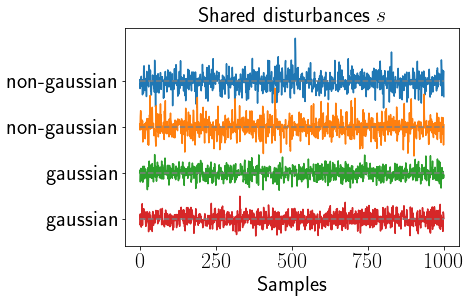

In [6]:
# plot shared disturbances s
def plot_shared_disturbances(S, nb_gaussian_disturbances, height=8, fontsize=22):
    p, n = S.shape
    fig, ax = plt.subplots(figsize=(6, 4))
    for i in range(p):
        plt.plot(S[i] - height * i)
        plt.hlines(y=-height*i, xmin=0, xmax=n, linestyles="--", colors="grey")
    plt.xlabel("Samples", fontsize=fontsize)
    plt.yticks(-np.arange(p) * height)
    yticklabels = ["non-gaussian"] * (p - nb_gaussian_disturbances) + ["gaussian"] * nb_gaussian_disturbances
    ax.set_yticklabels(yticklabels)
    plt.title(r"Shared disturbances $s$", fontsize=fontsize)
    plt.show()

plot_shared_disturbances(S, nb_gaussian_disturbances, fontsize=fontsize)

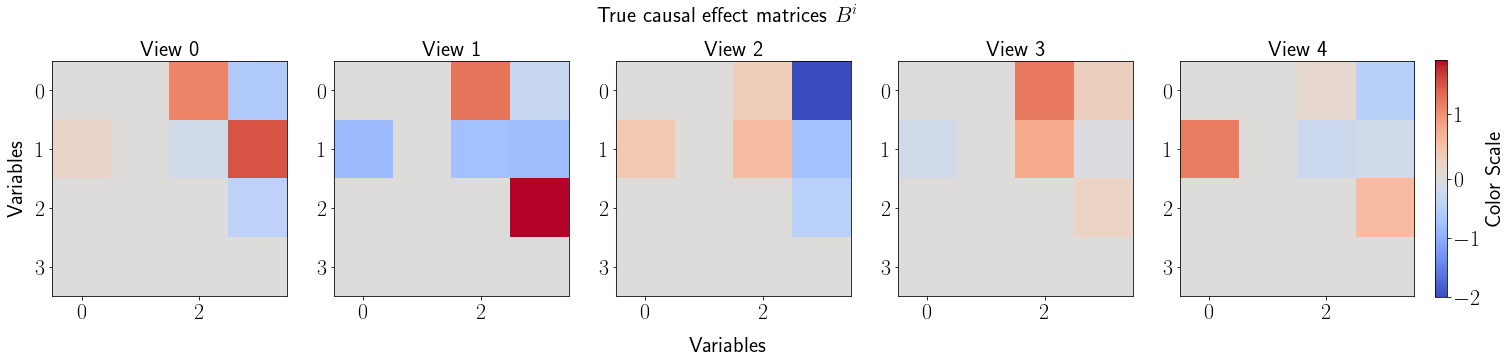

In [7]:
# plot heat maps of the true causal effect matrices Bi
def plot_heat_maps(B, title="", fontsize=22):
    m = len(B)
    fig, axes = plt.subplots(1, m, figsize=(m*5, 5))
    norm = TwoSlopeNorm(vmin=np.min(B), vmax=np.max(B), vcenter=0)
    for i, ax in enumerate(axes.flat):
        im = ax.imshow(B[i], norm=norm, cmap="coolwarm")
        ax.set_title(f"View {i}", fontsize=fontsize)
    cbar = fig.colorbar(im, ax=axes, fraction=0.0085, pad=0.015)
    cbar.set_label("Color Scale", fontsize=fontsize)
    fig.suptitle(f"{title}", fontsize=fontsize)
    fig.supxlabel("Variables", fontsize=fontsize)
    fig.supylabel("Variables", x=0.1, fontsize=fontsize)
    plt.show()

plot_heat_maps(B, title=r"True causal effect matrices $B^i$")

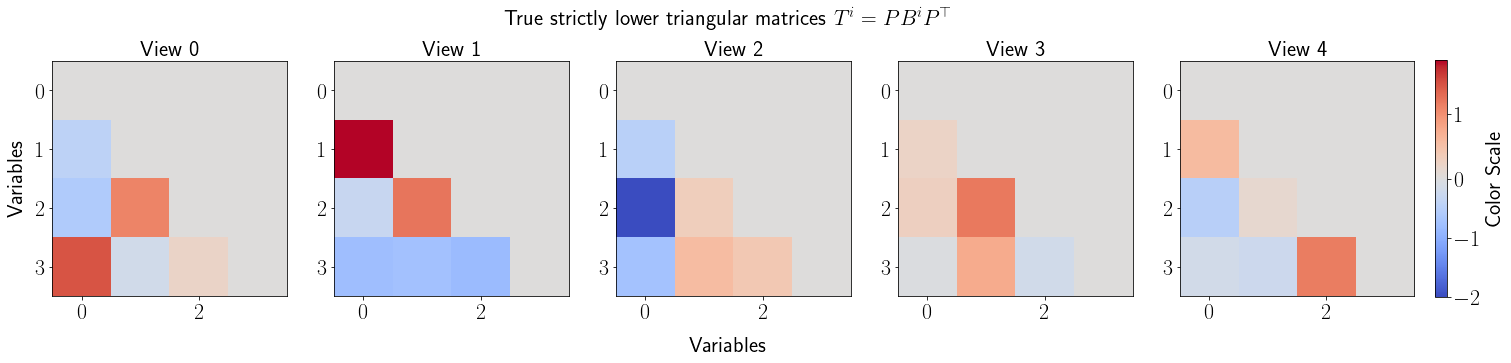

In [8]:
# plot the true strictly lower triangular matrices Ti
if shared_causal_ordering:
    title = r"True strictly lower triangular matrices $T^i = P B^i P^\top$"
else:
    title = r"True strictly lower triangular matrices $T^i = P^i B^i (P^i)^\top$"
plot_heat_maps(T, title=title)

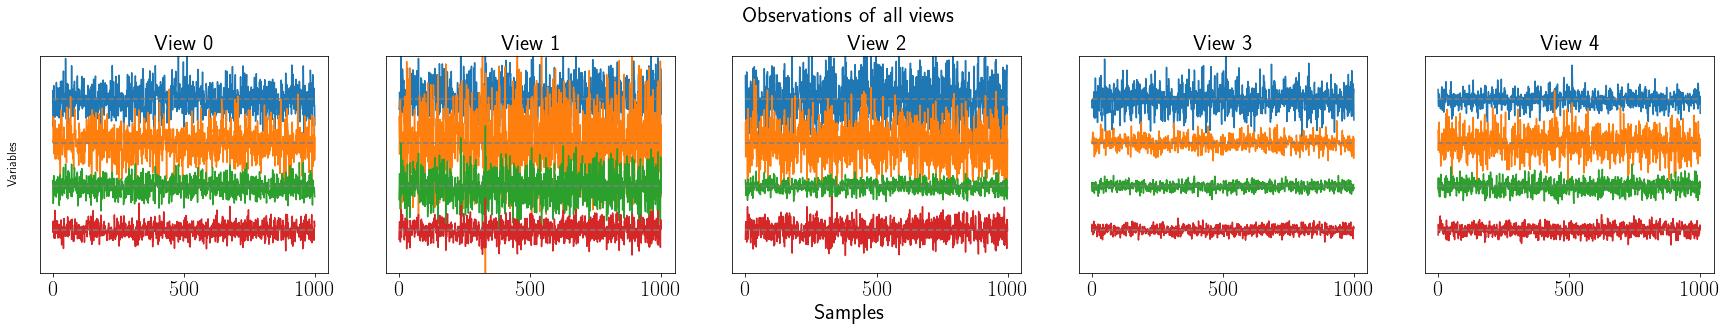

In [9]:
# plot observations xi
def plot_observations(X, height=10, fontsize=22):
    m, p, n = X.shape
    fig, axes = plt.subplots(1, m, figsize=(6*m, 4), sharex=True, sharey=True)
    for i in range(m):
        for j in range(p):
            axes[i].plot(X[i, j] - height * j)
            axes[i].hlines(y=-height*j, xmin=0, xmax=n, linestyles="--", colors="grey")
        axes[i].set_yticks([])
        axes[i].set_title(f"View {i}", fontsize=fontsize)
        axes[i].set_ylim([-p*height, height])
    fig.supxlabel("Samples", y=-0.05, fontsize=fontsize)
    fig.supylabel("Variables", x=0.11)
    fig.suptitle("Observations of all views", y=1.05, fontsize=fontsize)
    plt.show()

plot_observations(X, fontsize=fontsize)

# One run of ICA-LiMVAM

This section shows how to use our method (ICA-LiMVAM) in practice. Both variants (ICA-LiMVAM-ML or ICA-LiMVAM-J) can be used.

In [10]:
# apply ICA-LiMVAM to retrieve P and B; it takes more time when the variant ShICA-ML is used
B_estimates, T_estimates, P_estimate, _, _ = micado(
    X, shared_causal_ordering=shared_causal_ordering, ica_algo=ica_algo, random_state=random_state)

We can observe that ICA-LiMVAM takes far more time than our other methods DirectLiMVAM and PairwiseLiMVAM.

In [11]:
# print the shapes of variables B, T, and P
print(f"Shape of B_estimates : {B_estimates.shape}")
print(f"Shape of T_estimates : {T_estimates.shape}")
print(f"Shape of P_estimate : {P_estimate.shape}")

Shape of B_estimates : (5, 4, 4)
Shape of T_estimates : (5, 4, 4)
Shape of P_estimate : (4, 4)


Note that P_estimate has shape (p, p) when shared_causal_ordering==True, and shape (m, p, p) when shared_causal_ordering==False.

In [12]:
# check if the causal ordering(s) is (are) recovered
if shared_causal_ordering:
    if (P_estimate == P).all():
        print("The causal ordering is recovered!")
    else:
        print("The causal ordering is not recovered.")
else:
    score_P = np.sum([(Pe == Pi).all() for Pe, Pi in zip(P_estimate, P)])
    print(f"Number of views whose causal ordering is recovered : {score_P} / {m}")

The causal ordering is recovered!


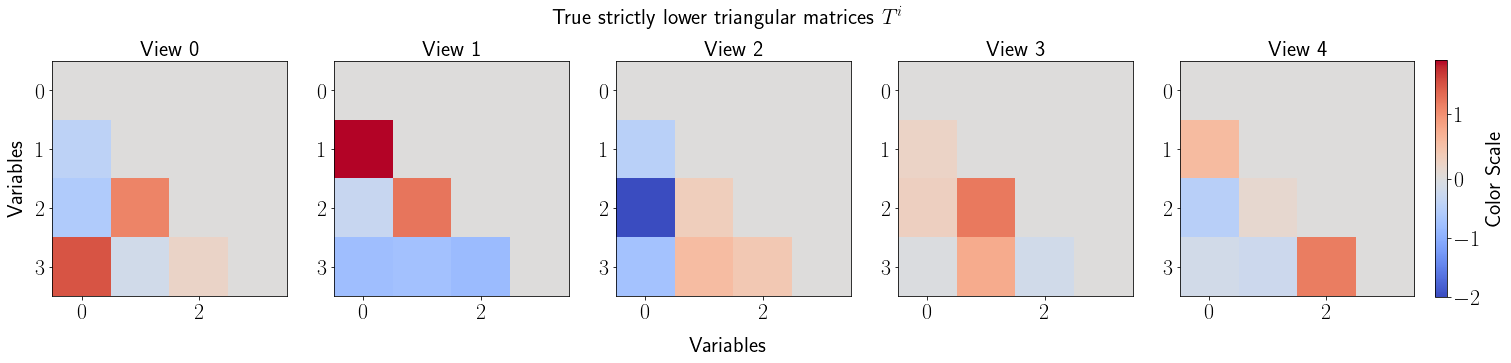

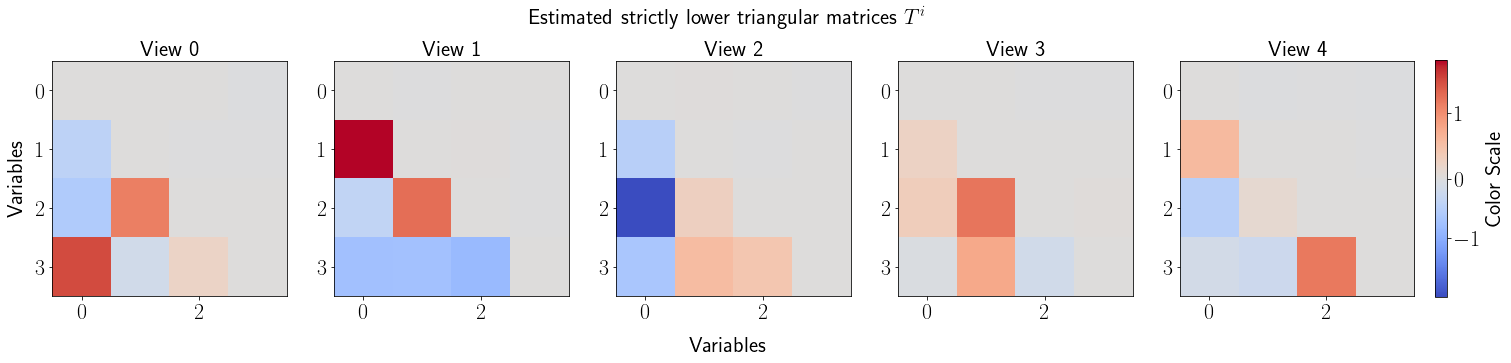

In [13]:
# plot true and estimated matrices Ti
plot_heat_maps(T, title=r"True strictly lower triangular matrices $T^i$")
plot_heat_maps(T_estimates, title=r"Estimated strictly lower triangular matrices $T^i$")

The matrices Ti are recovered!